# 1 Importing all libraries and data loading


In [1]:
# 1.1 Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_context("notebook")
pd.set_option("display.max_columns", 100)

# 1.2 loading the  modelling data that we created earlier
df = pd.read_csv("../data/wq_modelling.csv")
df["sample_date"] = pd.to_datetime(df["sample_date"])
df.shape, df.head()

((1484, 23),
                     station catchment             zone         sample_date  \
 0  RICHMOND RIVER AT CASINO  Richmond  Far North Coast 2016-06-28 11:45:00   
 1  RICHMOND RIVER AT CASINO  Richmond  Far North Coast 2016-08-18 12:27:00   
 2  RICHMOND RIVER AT CASINO  Richmond  Far North Coast 2016-09-29 11:18:00   
 3  RICHMOND RIVER AT CASINO  Richmond  Far North Coast 2016-10-26 10:21:00   
 4  RICHMOND RIVER AT CASINO  Richmond  Far North Coast 2016-11-29 08:57:00   
 
    year  month  season  ec_us_cm  total_n_mg_l  nox_n_mg_l  total_p_mg_l  \
 0  2016      6  winter     230.0          1.10        0.42         0.240   
 1  2016      8  winter     260.0          0.52        0.19         0.150   
 2  2016      9  spring     340.0          0.36        0.01         0.099   
 3  2016     10  spring     350.0          0.22        0.01         0.088   
 4  2016     11  spring     330.0          0.28        0.01         0.140   
 
    reactive_p_mg_l  tss_mg_l  turbidity_ntu  d

# 2 Building a time lagged data set for next month prediction
the purpose of this is to create features from previous sampling at each station and then label for if the next sampling is high concern or not

In [2]:
#2.1 sortingg by station and date so lags make sense
df = df.sort_values(["station", "sample_date"]).reset_index(drop=True)

#2.2 here we are creating lag-1 versions of key indicators and the current label
base_cols_for_lag = [
    "ec_us_cm",
    "total_n_mg_l",
    "nox_n_mg_l",
    "total_p_mg_l",
    "reactive_p_mg_l",
    "tss_mg_l",
    "turbidity_ntu",
    "do_sat_pct",
    "ph",
    "high_concern",
]

for col in base_cols_for_lag:
    df[f"{col}_lag1"] = df.groupby("station")[col].shift(1)

# here we define target: high_concern at the NEXT sampling for the same station
df["high_concern_next"] = df.groupby("station")["high_concern"].shift(-1)

# here we keep keep rows with complete lag features and next label
lag_feature_cols = [f"{c}_lag1" for c in base_cols_for_lag]
df_lag = df.dropna(subset=lag_feature_cols + ["high_concern_next"]).copy()
df_lag["high_concern_next"] = df_lag["high_concern_next"].astype(int)

df_lag.shape, df_lag["high_concern_next"].value_counts(normalize=True).round(3)

((1245, 34),
 high_concern_next
 0    0.884
 1    0.116
 Name: proportion, dtype: float64)

in this step we created a time lagged dataset in which each record has the previous sampling's indicator and then predicts weather the station will be high concern at it's next sampling

# 3 Defining features and target as well as preprocessing
in this step we choose which columns the model will use and also define preprocessing steps to handle the missing values and categorical variables in a pipeline which is reproducible

In [3]:
#3.1 features and target
target_col = "high_concern_next"

numeric_features = [
    "ec_us_cm_lag1",
    "total_n_mg_l_lag1",
    "nox_n_mg_l_lag1",
    "total_p_mg_l_lag1",
    "reactive_p_mg_l_lag1",
    "tss_mg_l_lag1",
    "turbidity_ntu_lag1",
    "do_sat_pct_lag1",
    "ph_lag1",
    "year",    # current year and month give seasonal context
    "month",
]

categorical_features = [
    "station",
    "catchment",
    "zone",
    "season",
]

X = df_lag[numeric_features + categorical_features].copy()
y = df_lag[target_col]

#3.2 train–test splitting which has been stratified to keep class balance
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

y_train.value_counts(normalize=True).round(3), y_test.value_counts(normalize=True).round(3)

(high_concern_next
 0    0.884
 1    0.116
 Name: proportion, dtype: float64,
 high_concern_next
 0    0.884
 1    0.116
 Name: proportion, dtype: float64)

# Pipeline
In this preprocessing pipeline below
for numeric we impute missing values with the median since it is robust to outliers and for categorical we impute misssing with most frequent category and then we one hot encode

In [4]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

4 Common evaluation helper
In order to avoid repeated code and then compute the same metgrics(accuracy,precision,recall,F1,AUC,ROC) for the all models we make a common evaluation helper function

In [5]:
def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Probabilities for AUC where available
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        y_proba = None
        auc = None

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    print(f"\n=== {name} ===")
    print(f"Accuracy : {acc:.3f}")
    print(f"Precision: {prec:.3f}")
    print(f"Recall   : {rec:.3f}")
    print(f"F1-score : {f1:.3f}")
    if auc is not None:
        print(f"ROC AUC  : {auc:.3f}")

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.show()

    if y_proba is not None:
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"ROC Curve – {name}")
        plt.show()

# Model 1 : Logistic Regression (Base Model)
simple linear baseline model which is easy to understand and gives a reference level of performance



=== Logistic Regression – next month ===
Accuracy : 0.767
Precision: 0.277
Recall   : 0.621
F1-score : 0.383
ROC AUC  : 0.814

Classification report:
              precision    recall  f1-score   support

           0       0.94      0.79      0.86       220
           1       0.28      0.62      0.38        29

    accuracy                           0.77       249
   macro avg       0.61      0.70      0.62       249
weighted avg       0.86      0.77      0.80       249



/Users/bilabthapa/wq_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


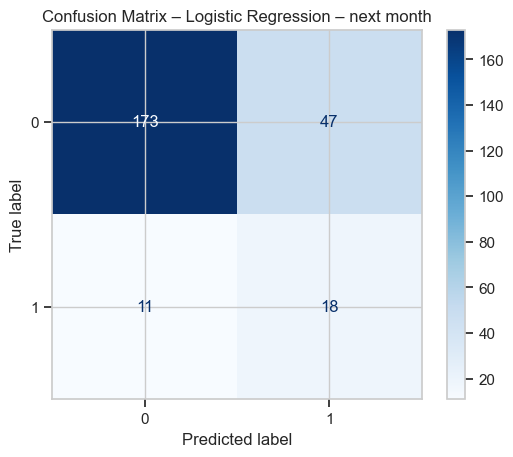

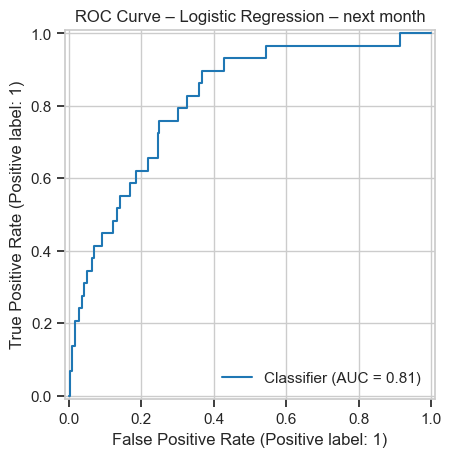

In [6]:
log_reg = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",  # handle class imbalance
            solver="lbfgs",
        )),
    ]
)

evaluate_model("Logistic Regression – next month", log_reg, X_train, X_test, y_train, y_test)

# Model 2 Decision Tree
a single decision tree can capture non linear interactions and thresholds , for eg , if turbidity_lag1 is high and DO_lag1 is low then risk is high . 


=== Decision Tree – next month ===
Accuracy : 0.823
Precision: 0.358
Recall   : 0.655
F1-score : 0.463
ROC AUC  : 0.759

Classification report:
              precision    recall  f1-score   support

           0       0.95      0.85      0.89       220
           1       0.36      0.66      0.46        29

    accuracy                           0.82       249
   macro avg       0.65      0.75      0.68       249
weighted avg       0.88      0.82      0.84       249



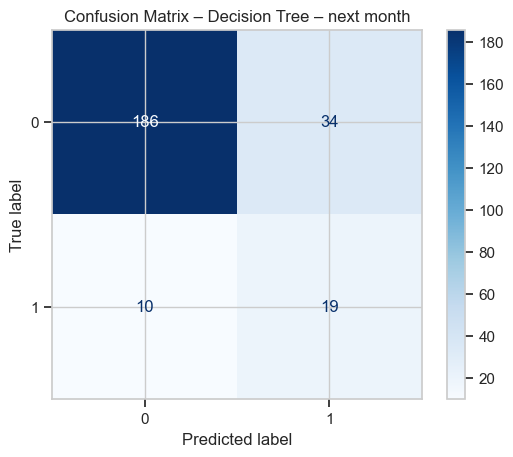

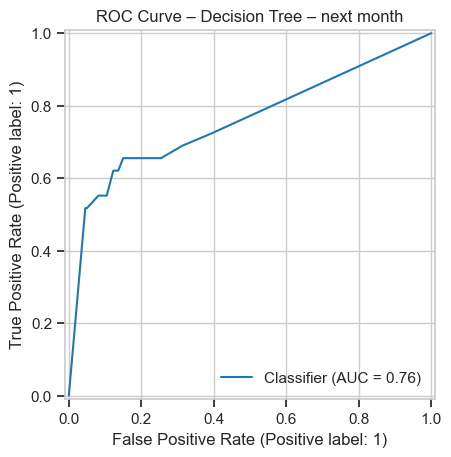

In [7]:
dt = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", DecisionTreeClassifier(
            max_depth=5,            # limit depth to reduce overfitting
            min_samples_split=20,   # require some samples per split
            random_state=42,
            class_weight="balanced",
        )),
    ]
)

evaluate_model("Decision Tree – next month", dt, X_train, X_test, y_train, y_test)

# Model 3 Random Forest
 in order to ensemble many decison trees, this usually achieves higher accuracy and more stable predicitons then single trees or logistic regression
 


=== Random Forest – next month ===
Accuracy : 0.892
Precision: 0.550
Recall   : 0.379
F1-score : 0.449
ROC AUC  : 0.842

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94       220
           1       0.55      0.38      0.45        29

    accuracy                           0.89       249
   macro avg       0.74      0.67      0.69       249
weighted avg       0.88      0.89      0.88       249



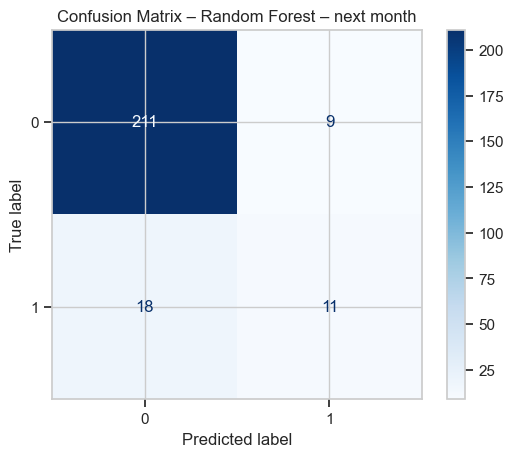

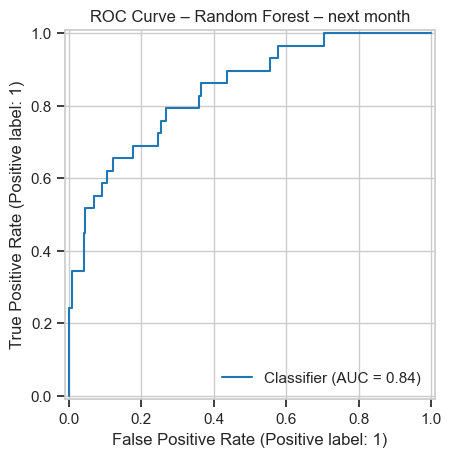

In [8]:
rf = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("clf", RandomForestClassifier(
            n_estimators=500,            # number of trees
            max_depth=None,             # let trees grow, other params regularise
            min_samples_split=10,
            random_state=42,
            class_weight="balanced_subsample",
            n_jobs=-1,
        )),
    ]
)

evaluate_model("Random Forest – next month", rf, X_train, X_test, y_train, y_test)

# Model 4 KNN

In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


=== KNN – next month ===
Accuracy : 0.855
Precision: 0.316
Recall   : 0.207
F1-score : 0.250
ROC AUC  : 0.652

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       220
           1       0.32      0.21      0.25        29

    accuracy                           0.86       249
   macro avg       0.61      0.57      0.58       249
weighted avg       0.83      0.86      0.84       249



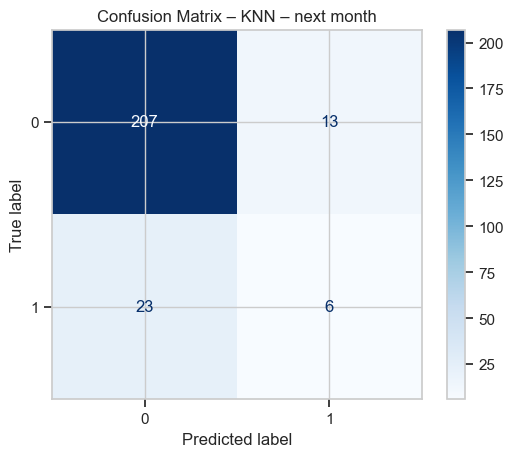

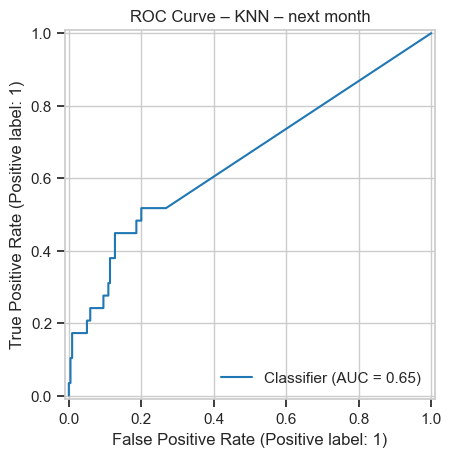

In [12]:
# Model 4 : KNN (Distance-based model)
# KNN requires scaling, so we explicitly add StandardScaler in pipeline

knn = Pipeline(
    steps=[
        ("preprocess", preprocess),
        ("scaler", StandardScaler(with_mean=False)),  # safe for one-hot sparse matrices
        ("clf", KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",   # improves performance in imbalance cases
            metric="minkowski"
        )),
    ]
)

evaluate_model("KNN – next month", knn, X_train, X_test, y_train, y_test)

# Comparison Table
in order to summarise the results of all models on same metrics so it is easy to report the best one


In [ ]:
results = []

def collect_metrics(name, model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
    else:
        auc = np.nan

    results.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": auc,
    })

models = {
    "Logistic Regression – next month": log_reg,
    "Decision Tree – next month": dt,
    "Random Forest – next month": rf,
    "KNN – next month": knn,
}

for name, model in models.items():
    collect_metrics(name, model)

results_df = pd.DataFrame(results).round(3)
results_df

/Users/bilabthapa/wq_env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression – next month,0.767,0.277,0.621,0.383,0.814
1,Decision Tree – next month,0.823,0.358,0.655,0.463,0.759
2,Random Forest – next month,0.892,0.550,0.379,0.449,0.842


In [11]:
results_df.to_csv("../reports/figures/next_month_model_comparison.csv", index=False)